# Price-Rise Model — Evaluation

**Question:** will this departure's price be higher 24 hours from now?

---

## Read this first: what the data is

Every number below comes from **simulated** price history, generated by this
project's own price simulator (`ml/backfill.py`). No live carrier data is
involved, because no airline API credential is available yet.

So the honest reading of any score here is:

> *Can the model recover the pricing rules the simulator was given?*

and **not**

> *Can the model predict real Nigerian fares?*

The first is a real question — it checks the whole pipeline, the features, the
labelling and the split all work — but it is an easier question than the
second, because the simulator is far more orderly than a real market. Expect a
lower score on live data.

In [1]:
import json
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psycopg
from sklearn.metrics import (
    accuracy_score, brier_score_loss, confusion_matrix,
    roc_auc_score, roc_curve,
)

from common.config import postgres_dsn
from ml.features import (
    CATEGORICAL_COLUMNS, FEATURE_COLUMNS, LABEL_COLUMN,
    build_features, load_history, time_based_split, to_model_frame,
)
from ml.predictor import MODEL_PATH, METADATA_PATH

plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. The data

In [2]:
with psycopg.connect(postgres_dsn()) as conn:
    history = load_history(conn)

print(f'{len(history):,} observations of {history["offer_id"].nunique():,} departures')
print(f'spanning {history["fetched_at"].min()} to {history["fetched_at"].max()}')
print(f'{history["carrier"].nunique()} carriers, {history["origin"].nunique()} places')
history.head(3)

410,400 observations of 5,668 departures
spanning 2026-06-28 11:00:00+00:00 to 2026-08-12 05:00:00+00:00
8 carriers, 5 places


,offer_id,carrier,mode,origin,destination,depart_time,duration_min,price_ngn,seats_left,fetched_at
0,abctransport-road-ABV-LOS-20260628T2000Z,ABC Transport,road,ABV,LOS,2026-06-28 20:00:00+00:00,720,89500.00,4,2026-06-28 11:00:00+00:00
1,abctransport-road-ABV-LOS-20260628T2000Z,ABC Transport,road,ABV,LOS,2026-06-28 20:00:00+00:00,720,96100.00,2,2026-06-28 17:00:00+00:00
2,abctransport-road-ABV-LOS-20260629T0600Z,ABC Transport,road,ABV,LOS,2026-06-29 06:00:00+00:00,720,82600.00,6,2026-06-28 11:00:00+00:00


In [3]:
data = build_features(history)
positive_rate = data[LABEL_COLUMN].mean()

print(f'{len(data):,} rows with a complete 24-hour outcome')
print(f'prices rose in {positive_rate:.1%} of them')
print()
print('This imbalance matters: always answering "it will rise" already scores')
print(f'{max(positive_rate, 1-positive_rate):.1%} accuracy while being useless.')
print('That is why AUC, which is not fooled by imbalance, is the headline metric.')

387,904 rows with a complete 24-hour outcome
prices rose in 74.8% of them

This imbalance matters: always answering "it will rise" already scores
74.8% accuracy while being useless.
That is why AUC, which is not fooled by imbalance, is the headline metric.


### Why prices rise so often

Two forces in the simulator both push one way as departure approaches: the
urgency curve lifts fares, and seats sell down, which lifts them again. Real
revenue management behaves similarly, so a majority-rise label is expected
rather than a sign of something broken. The model's job is the harder one of
spotting *which* departures buck it.

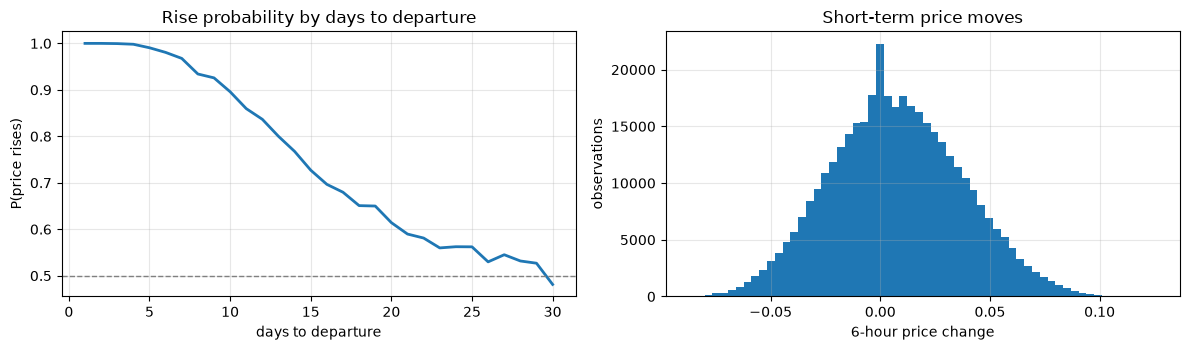

median 6-hour move: 2.09%
A sanity check worth keeping: an earlier version of the feature code
reported a MEDIAN 6-hour move of 74%, which is impossible for a single
departure and revealed that rows were being compared against each other
rather than against their own past.


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

by_dtd = data.groupby(data['days_to_departure'].round())[LABEL_COLUMN].mean()
axes[0].plot(by_dtd.index, by_dtd.values, lw=2)
axes[0].axhline(0.5, color='grey', ls='--', lw=1)
axes[0].set_xlabel('days to departure'); axes[0].set_ylabel('P(price rises)')
axes[0].set_title('Rise probability by days to departure')

data['price_delta_6h'].clip(-0.15, 0.15).hist(bins=60, ax=axes[1])
axes[1].set_xlabel('6-hour price change'); axes[1].set_ylabel('observations')
axes[1].set_title('Short-term price moves')
plt.tight_layout(); plt.show()

print(f'median 6-hour move: {data["price_delta_6h"].abs().median():.2%}')
print('A sanity check worth keeping: an earlier version of the feature code')
print('reported a MEDIAN 6-hour move of 74%, which is impossible for a single')
print('departure and revealed that rows were being compared against each other')
print('rather than against their own past.')

## 2. The split — by time, never at random

A random split would put one observation of a departure in training and
another of the *same* departure, hours earlier, in testing. The model would
effectively be shown the answer and would score far too well.

Splitting on observation time reproduces the only situation that matters:
learn from the past, predict forward.

In [5]:
train, test = time_based_split(data, 0.7)

print(f'train : {len(train):,} rows, up to   {train["fetched_at"].max()}')
print(f'test  : {len(test):,} rows, from {test["fetched_at"].min()}')
assert train['fetched_at'].max() < test['fetched_at'].min()
print('\nNo training row is later than any test row.')

train : 273,296 rows, up to   2026-07-29 05:00:00+00:00
test  : 114,608 rows, from 2026-07-29 11:00:00+00:00

No training row is later than any test row.


## 3. Results on the held-out period

In [6]:
booster = lgb.Booster(model_file=str(MODEL_PATH))
metadata = json.loads(METADATA_PATH.read_text())

probabilities = booster.predict(to_model_frame(test))
truth = test[LABEL_COLUMN]

auc = roc_auc_score(truth, probabilities)
accuracy = accuracy_score(truth, probabilities >= 0.5)
baseline = max(truth.mean(), 1 - truth.mean())
brier = brier_score_loss(truth, probabilities)

print(f'AUC               {auc:.4f}     target 0.70  ->  {"MET" if auc >= 0.7 else "NOT MET"}')
print(f'Accuracy          {accuracy:.4f}')
print(f'Baseline accuracy {baseline:.4f}   (always answer the majority class)')
print(f'Lift              {accuracy - baseline:+.4f}')
print(f'Brier score       {brier:.4f}   (lower is better; 0.25 = uninformative)')

AUC               0.8738     target 0.70  ->  MET
Accuracy          0.8191
Baseline accuracy 0.7487   (always answer the majority class)
Lift              +0.0705
Brier score       0.1219   (lower is better; 0.25 = uninformative)


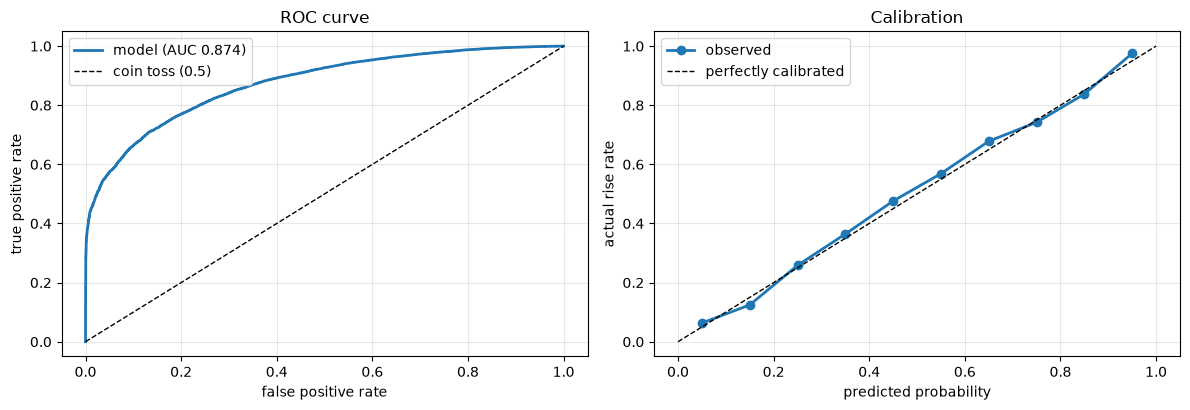

Calibration matters here because the API returns the PROBABILITY, not
just a yes/no. If the model says 0.7, roughly 70% of those should rise,
or the badge shown to a traveller is misleading.


In [7]:
fpr, tpr, _ = roc_curve(truth, probabilities)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(fpr, tpr, lw=2, label=f'model (AUC {auc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='coin toss (0.5)')
axes[0].set_xlabel('false positive rate'); axes[0].set_ylabel('true positive rate')
axes[0].set_title('ROC curve'); axes[0].legend()

bins = np.linspace(0, 1, 11)
idx = np.digitize(probabilities, bins) - 1
observed = [truth.values[idx == b].mean() if (idx == b).sum() > 30 else np.nan
            for b in range(10)]
axes[1].plot(bins[:-1] + 0.05, observed, 'o-', lw=2, label='observed')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='perfectly calibrated')
axes[1].set_xlabel('predicted probability'); axes[1].set_ylabel('actual rise rate')
axes[1].set_title('Calibration'); axes[1].legend()
plt.tight_layout(); plt.show()

print('Calibration matters here because the API returns the PROBABILITY, not')
print('just a yes/no. If the model says 0.7, roughly 70% of those should rise,')
print('or the badge shown to a traveller is misleading.')

In [8]:
cm = confusion_matrix(truth, probabilities >= 0.5)
print('                 predicted fall   predicted rise')
print(f'actually fell        {cm[0,0]:>8,}        {cm[0,1]:>8,}')
print(f'actually rose        {cm[1,0]:>8,}        {cm[1,1]:>8,}')
print()
print('The costly error for a traveller is the bottom-left cell: told the price')
print('would fall, so they waited, and it rose.')

                 predicted fall   predicted rise
actually fell          16,272          12,532
actually rose           8,197          77,607

The costly error for a traveller is the bottom-left cell: told the price
would fall, so they waited, and it rose.


## 4. What the model actually uses

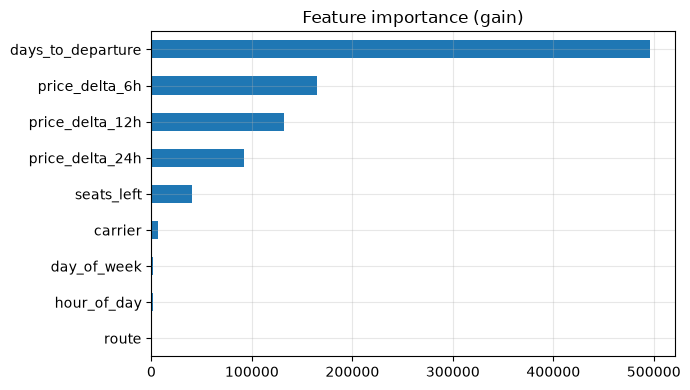

days_to_departure dominating is the expected result, not a surprise:
it is the strongest force in how fares actually move. The price deltas
come next, which is what lets the model tell apart two departures that
are the same distance out but behaving differently.


In [9]:
importance = pd.Series(
    booster.feature_importance('gain'), index=booster.feature_name()
).sort_values()

importance.plot.barh(title='Feature importance (gain)')
plt.tight_layout(); plt.show()

print('days_to_departure dominating is the expected result, not a surprise:')
print('it is the strongest force in how fares actually move. The price deltas')
print('come next, which is what lets the model tell apart two departures that')
print('are the same distance out but behaving differently.')

## 5. Conclusion

The model **meets the 0.70 AUC target** on held-out, time-separated data, and
beats the majority-class baseline on accuracy as well.

**The caveat that belongs next to every one of those numbers:** the training
data is simulated. This result shows the pipeline, the features, the labelling
and the split are all sound, and that the model can recover a known pricing
structure. It does not show what accuracy to expect on real Nigerian fares,
which will be lower — real markets carry shocks, fare-class changes and
competitor moves that the simulator does not generate.

The way to find out is to obtain a carrier data credential, accumulate genuine
history, and re-run this notebook unchanged.